In [75]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import scipy.stats as stats
from scipy.stats import poisson
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

In [76]:
# Importing dataset

path = r'data\dataset.csv'

with open(path, encoding = 'UTF-8') as file:
    data = pd.read_csv(file)

# print(data.columns)
data

,year,month,day,home_team,away_team,stage,result,shootouts,home_score,home_is_host,...,away_draws_last_4y,away_wc_titles_before,away_total_market_value_eur,away_avg_age,away_wc_participations_before,away_groups_passed_before,away_round16_before,away_quarterfinals_before,away_semifinals_before,away_finals_before
0,2006,6,9,Germany,Costa Rica,0,0.0,0,4.0,1,...,11,0,1.840000e+07,24.7,2,1,1,0,0,0
1,2006,6,9,Poland,Ecuador,0,1.0,0,0.0,0,...,12,0,3.878300e+08,25.7,1,0,0,0,0,0
2,2006,6,10,Argentina,Ivory Coast,0,0.0,0,2.0,0,...,8,0,4.109000e+08,25.8,0,0,0,0,0,0
3,2006,6,10,England,Paraguay,0,0.0,0,1.0,0,...,17,0,1.418500e+08,29.1,6,3,3,0,0,0
4,2006,6,10,Trinidad and Tobago,Sweden,0,2.0,0,0.0,0,...,18,0,3.637800e+08,26.3,10,7,3,4,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
415,2026,7,7,Switzerland,Colombia,1,0.0,1,0.0,0,...,11,0,2.851000e+08,29.3,6,3,3,1,0,0
416,2026,7,9,France,Morocco,1,0.0,0,2.0,0,...,9,0,4.355500e+08,27.4,6,2,2,1,1,0
417,2026,7,10,Spain,Belgium,1,0.0,0,2.0,0,...,10,0,4.422000e+08,27.1,14,9,8,3,2,0
418,2026,7,11,Norway,England,1,1.0,0,1.0,0,...,7,1,1.300000e+09,26.8,16,13,8,10,3,1


In [77]:
# Duplicating dataset to obtain 2 different rows for every match

home_col = ['year', 'month', 'day', 'home_team', 'away_team', 'stage',
    'shootouts', 'home_score', 'home_is_host', 'home_goals_scored_last_4y',
    'home_goals_received_last_4y', 'home_wins_last_4y',
    'home_losses_last_4y', 'home_draws_last_4y', 'home_wc_titles_before',
    'home_total_market_value_eur', 'home_avg_age',
    'home_wc_participations_before', 'home_groups_passed_before',
    'home_round16_before', 'home_quarterfinals_before',
    'home_semifinals_before', 'home_finals_before',
    'away_is_host', 'away_goals_scored_last_4y',
    'away_goals_received_last_4y', 'away_wins_last_4y',
    'away_losses_last_4y', 'away_draws_last_4y', 'away_wc_titles_before',
    'away_total_market_value_eur', 'away_avg_age',
    'away_wc_participations_before', 'away_groups_passed_before',
    'away_round16_before', 'away_quarterfinals_before',
    'away_semifinals_before', 'away_finals_before']

away_col = ['year', 'month', 'day', 'away_team', 'home_team', 'stage',
    'shootouts', 'away_score', 'away_is_host', 'away_goals_scored_last_4y',
    'away_goals_received_last_4y', 'away_wins_last_4y',
    'away_losses_last_4y', 'away_draws_last_4y', 'away_wc_titles_before',
    'away_total_market_value_eur', 'away_avg_age',
    'away_wc_participations_before', 'away_groups_passed_before',
    'away_round16_before', 'away_quarterfinals_before',
    'away_semifinals_before', 'away_finals_before', 'home_is_host', 'home_goals_scored_last_4y',
    'home_goals_received_last_4y', 'home_wins_last_4y',
    'home_losses_last_4y', 'home_draws_last_4y', 'home_wc_titles_before',
    'home_total_market_value_eur', 'home_avg_age',
    'home_wc_participations_before', 'home_groups_passed_before',
    'home_round16_before', 'home_quarterfinals_before',
    'home_semifinals_before', 'home_finals_before']

new_col = ['year', 'month', 'day',
    'team', 'opponent', 'stage','shootouts', 'goals', 'team_host',
    'team_goals_last4y', 'team_received_last4y',
    'team_wins_last4y', 'team_losses_last4y', 'team_draws_last4y',
    'team_wc_titles', 'team_market_value_eur', 'team_avg_age',
    'team_wc_participations', 'team_groups_passed',
    'team_round16', 'team_quarterfinals',
    'team_semifinals', 'team_finals',
    'opponent_host',
    'opponent_goals_last4y', 'opponent_received_last4y',
    'opponent_wins_last4y', 'opponent_losses_last4y', 'opponent_draws_last4y',
    'opponent_wc_titles', 'opponent_market_value_eur', 'opponent_avg_age',
    'opponent_wc_participations', 'opponent_groups_passed',
    'opponent_round16', 'opponent_quarterfinals',
    'opponent_semifinals', 'opponent_finals']


home_data = pd.DataFrame(data[home_col]).copy()
home_data.columns = new_col

away_data = pd.DataFrame(data[away_col]).copy()
away_data.columns = new_col


# Creating a unique dataset for the model

poisson_df = pd.concat([home_data, away_data], ignore_index=True) #.dropna()
poisson_df['year'] = pd.to_numeric(poisson_df['year'])
poisson_df

,year,month,day,team,opponent,stage,shootouts,goals,team_host,team_goals_last4y,...,opponent_draws_last4y,opponent_wc_titles,opponent_market_value_eur,opponent_avg_age,opponent_wc_participations,opponent_groups_passed,opponent_round16,opponent_quarterfinals,opponent_semifinals,opponent_finals
0,2006,6,9,Germany,Costa Rica,0,0,4.0,1,107,...,11,0,1.840000e+07,24.7,2,1,1,0,0,0
1,2006,6,9,Poland,Ecuador,0,0,0.0,0,102,...,12,0,3.878300e+08,25.7,1,0,0,0,0,0
2,2006,6,10,Argentina,Ivory Coast,0,0,2.0,0,97,...,8,0,4.109000e+08,25.8,0,0,0,0,0,0
3,2006,6,10,England,Paraguay,0,0,1.0,0,83,...,17,0,1.418500e+08,29.1,6,3,3,0,0,0
4,2006,6,10,Trinidad and Tobago,Sweden,0,0,0.0,0,99,...,18,0,3.637800e+08,26.3,10,7,3,4,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
835,2026,7,7,Colombia,Switzerland,1,1,0.0,0,73,...,16,0,2.510000e+08,27.5,12,8,7,3,0,0
836,2026,7,9,Morocco,France,1,0,0.0,0,100,...,7,2,1.290000e+09,26.7,16,10,8,9,7,4
837,2026,7,10,Belgium,Spain,1,0,1.0,0,80,...,8,1,1.150000e+09,27.2,16,11,9,6,2,1
838,2026,7,11,England,Norway,1,0,2.0,0,82,...,6,0,5.029000e+08,26.0,3,2,2,0,0,0


In [78]:
# Preparing for a cross-validation leaving one year out every time to evaluate differences in different models and test them on test set

years = [2006, 2010, 2014, 2018, 2022, 2026]
scal_features = ['stage','shootouts', 'team_host',
       'team_goals_last4y', 'team_received_last4y',
       'team_wins_last4y', 'team_losses_last4y', 'team_draws_last4y',
       'team_wc_titles', 'team_market_value_eur', 'team_avg_age',
       'team_wc_participations', 'team_groups_passed',
       'team_round16', 'team_quarterfinals',
       'team_semifinals', 'team_finals',
       'opponent_host',
       'opponent_goals_last4y', 'opponent_received_last4y',
       'opponent_wins_last4y', 'opponent_losses_last4y', 'opponent_draws_last4y',
       'opponent_wc_titles', 'opponent_market_value_eur', 'opponent_avg_age',
       'opponent_wc_participations', 'opponent_groups_passed',
       'opponent_round16', 'opponent_quarterfinals',
       'opponent_semifinals', 'opponent_finals']

goal_mean_accuracy = []
prediction_mean_accuracy = []
intervals_mean_accuracy = []

test_goal_mean_accuracy = []
test_prediction_mean_accuracy = []
test_intervals_mean_accuracy = []

for y in years:
   train = poisson_df[poisson_df['year'] != y][new_col].copy()
   test = poisson_df[poisson_df['year'] == y][new_col].copy()

   scaler = StandardScaler()

   train[scal_features] = scaler.fit_transform(train[scal_features])
   test[scal_features] = scaler.transform(test[scal_features])

   formula = 'goals ~ shootouts + team_host + team_market_value_eur + opponent_market_value_eur'
   
   model = smf.poisson(formula, data=train).fit(disp=0)

   train['goals_pred'] = model.predict(train)  
   intervals = model.get_prediction(train).conf_int(alpha = 0.05)

   train['lower_bound'] = np.floor(intervals[:, 0])
   train['upper_bound'] = np.ceil(intervals[:, 1])


   m = (train.shape[0]//2)
   train_1 = train.iloc[ :m, :].copy().reset_index(drop=True)
   train_2 = train.iloc[m:, :].copy().reset_index(drop=True)

   y_true = train_1['goals'].astype(int).astype(str) + "-" + train_2['goals'].astype(int).astype(str)
   y_pred = train_1['goals_pred'].round(0).astype(int).astype(str) + "-" + train_2['goals_pred'].round(0).astype(int).astype(str)
   
   count = 0

   for i in range(m):
   
      if ((train_1['goals'].iloc[i]<=train_1['upper_bound'].iloc[i]) & (train_1['goals'].iloc[i]>=train_1['lower_bound'].iloc[i])) & ((train_2['goals'].iloc[i]<=train_2['upper_bound'].iloc[i]) & (train_2['goals'].iloc[i]>=train_2['lower_bound'].iloc[i])):
         count += 1

   goal_accuracy = accuracy_score(train['goals'], train['goals_pred'].round())
   prediction_accuracy = accuracy_score(y_true, y_pred)
   intervals_accuracy = count / m

   goal_mean_accuracy.append(goal_accuracy)
   prediction_mean_accuracy.append(prediction_accuracy)
   intervals_mean_accuracy.append(intervals_accuracy)


   test['goals_pred'] = model.predict(test)  
   test_intervals = model.get_prediction(test).conf_int(alpha = 0.05)

   test['lower_bound'] = np.floor(test_intervals[:, 0])
   test['upper_bound'] = np.ceil(test_intervals[:, 1])


   test_m = (test.shape[0]//2)
   test_1 = test.iloc[ :test_m, :].copy().reset_index(drop=True)
   test_2 = test.iloc[test_m:, :].copy().reset_index(drop=True)

   test_y_true = test_1['goals'].astype(int).astype(str) + "-" + test_2['goals'].astype(int).astype(str)
   test_y_pred = test_1['goals_pred'].round(0).astype(int).astype(str) + "-" + test_2['goals_pred'].round(0).astype(int).astype(str)
   
   count = 0

   for i in range(test_m):
   
      if (test_1['goals'].iloc[i]<=test_1['upper_bound'].iloc[i]) & (test_1['goals'].iloc[i]>=test_1['lower_bound'].iloc[i]) & (test_2['goals'].iloc[i]<=test_2['upper_bound'].iloc[i]) & (test_2['goals'].iloc[i]>=test_2['lower_bound'].iloc[i]):
         count += 1

   test_goal_accuracy = accuracy_score(test['goals'], test['goals_pred'].round())
   test_prediction_accuracy = accuracy_score(test_y_true, test_y_pred)
   test_intervals_accuracy = count / test_m

   test_goal_mean_accuracy.append(test_goal_accuracy)
   test_prediction_mean_accuracy.append(test_prediction_accuracy)
   test_intervals_mean_accuracy.append(test_intervals_accuracy)

   print(f"\n============================= ANNO DI TEST: {y} =============================")
   print(model.summary())
   print('\n====== ACCURACY ON TRAIN SET ======')
   print(f'Single goal accuracy: {goal_accuracy*100:.2f}%')
   print(f'Exact result accuracy: {prediction_accuracy*100:.2f}%')
   print(f'Confidence intervals accuracy: {intervals_accuracy*100:.2f}%')
   print('\n====== ACCURACY ON TEST SET ======')
   print(f'Single goal accuracy: {test_goal_accuracy*100:.2f}%')
   print(f'Exact result accuracy: {test_prediction_accuracy*100:.2f}%')
   print(f'Confidence intervals accuracy: {test_intervals_accuracy*100:.2f}%')

print(f"\n============================= ACCURACY SUMMARY ON TRAIN =============================")
print(f'Single goal accuracy mean: {sum(goal_mean_accuracy)/len(goal_mean_accuracy)*100:.2f}%')
print(f'Exact result accuracy mean: {sum(prediction_mean_accuracy)/len(prediction_mean_accuracy)*100:.2f}%')
print(f'Confidence intervals accuracy mean: {sum(intervals_mean_accuracy)/len(intervals_mean_accuracy)*100:.2f}%')
print(f"\n============================= ACCURACY SUMMARY ON TEST =============================")
print(f'Single goal accuracy mean: {sum(test_goal_mean_accuracy)/len(test_goal_mean_accuracy)*100:.2f}%')
print(f'Exact result accuracy mean: {sum(test_prediction_mean_accuracy)/len(test_prediction_mean_accuracy)*100:.2f}%')
print(f'Confidence intervals accuracy mean: {sum(test_intervals_mean_accuracy)/len(test_intervals_mean_accuracy)*100:.2f}%')



============================= ANNO DI TEST: 2006 =============================
                          Poisson Regression Results                          
Dep. Variable:                  goals   No. Observations:                  712
Model:                        Poisson   Df Residuals:                      707
Method:                           MLE   Df Model:                            4
Date:                Fri, 17 Jul 2026   Pseudo R-squ.:                 0.05301
Time:                        18:05:41   Log-Likelihood:                -1028.2
converged:                       True   LL-Null:                       -1085.8
Covariance Type:            nonrobust   LLR p-value:                 5.885e-24
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                     0.2265      0.034      6.579      0.000       0.159       0.294
shooto

In [79]:
# Creating a dataset for semi-finals

semi_finalist = poisson_df.loc[((poisson_df['team'].isin(['France', 'Spain', 'England', 'Argentina'])) & (poisson_df['year'] == 2026)), ['team', 'team_host', 'team_market_value_eur']].drop_duplicates().copy()
semi_finalist['shootouts'] = 0
semi_finalist['opponent_market_value_eur'] = semi_finalist['team_market_value_eur'].iloc[[1, 0, 3, 2]].values

semi_finalist

,team,team_host,team_market_value_eur,shootouts,opponent_market_value_eur
334,Spain,0,1.150000e+09,0,1.290000e+09
336,France,0,1.290000e+09,0,1.150000e+09
338,Argentina,0,5.750000e+08,0,1.300000e+09
342,England,0,1.300000e+09,0,5.750000e+08


In [80]:
# Fitting the model on full dataset

scaler = StandardScaler()

scal_features = ['team_host', 'team_market_value_eur', 'shootouts', 'opponent_market_value_eur']

train = poisson_df.copy()
train[scal_features] = scaler.fit_transform(train[scal_features])


formula = 'goals ~ shootouts + team_host + team_market_value_eur + opponent_market_value_eur'
model = smf.poisson(formula, data = train).fit(disp = 0)


========== FRANCE - SPAIN STATISTICS ==========

France 1.21 - 1.00 Spain
C.I. for France = [0.0 -- 2.0]
C.I. for Spain = [0.0 -- 2.0]


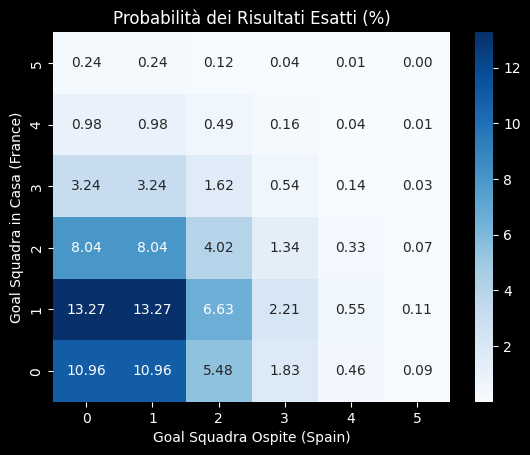


========== FRANCE - SPAIN STATISTICS ==========

England 1.87 - 0.69 Argentina
C.I. for England = [1.0 -- 3.0]
C.I. for Argentina = [0.0 -- 1.0]


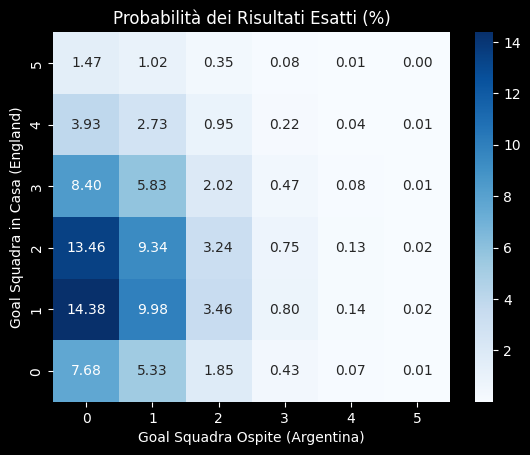

In [81]:
# Adding prediction statistics

semi_finalist[scal_features] = scaler.transform(semi_finalist[scal_features])

semi_finalist['expected_goals'] = model.predict(semi_finalist)

intervals = model.get_prediction(semi_finalist).conf_int(alpha = 0.05)

semi_finalist['lower_bound'] = np.floor(intervals[:, 0])
semi_finalist['upper_bound'] = np.ceil(intervals[:, 1])

semi_finalist

# Semi-finals predictions

array_goal = np.arange(6)

# Lets predict France-Spain final score

lambd_home = semi_finalist['expected_goals'].iloc[1]
lambd_away = semi_finalist['expected_goals'].iloc[0]

probhome = poisson.pmf(array_goal, lambd_home)
probaway = poisson.pmf(array_goal, lambd_away)

M = np.outer(probhome, probaway)

matrix = pd.DataFrame(M*100)

print('\n========== FRANCE - SPAIN STATISTICS ==========')
print(f'\nFrance {lambd_home:.2f} - {lambd_away:.2f} Spain')
print(f"C.I. for France = [{semi_finalist['lower_bound'].iloc[1]} -- {semi_finalist['upper_bound'].iloc[1]}]")
print(f"C.I. for Spain = [{semi_finalist['lower_bound'].iloc[1]} -- {semi_finalist['upper_bound'].iloc[1]}]")

plt.style.use('dark_background')
sns.heatmap(matrix, annot=True, fmt=".2f", cmap="Blues", cbar=True)
plt.gca().invert_yaxis()
plt.title("Probabilità dei Risultati Esatti (%)")
plt.ylabel("Goal Squadra in Casa (France)")
plt.xlabel("Goal Squadra Ospite (Spain)")
plt.show()


# Lets predict England-Argentina final score

lambd_home = semi_finalist['expected_goals'].iloc[3]
lambd_away = semi_finalist['expected_goals'].iloc[2]

probhome = poisson.pmf(array_goal, lambd_home)
probaway = poisson.pmf(array_goal, lambd_away)

M = np.outer(probhome, probaway)

print('\n========== FRANCE - SPAIN STATISTICS ==========')
print(f'\nEngland {lambd_home:.2f} - {lambd_away:.2f} Argentina')
print(f"C.I. for England = [{semi_finalist['lower_bound'].iloc[3]} -- {semi_finalist['upper_bound'].iloc[3]}]")
print(f"C.I. for Argentina = [{semi_finalist['lower_bound'].iloc[2]} -- {semi_finalist['upper_bound'].iloc[2]}]")

matrix = pd.DataFrame(M*100)
plt.style.use('dark_background')
sns.heatmap(matrix, annot=True, fmt=".2f", cmap="Blues", cbar=True)
plt.gca().invert_yaxis()
plt.title("Probabilità dei Risultati Esatti (%)")
plt.ylabel("Goal Squadra in Casa (England)")
plt.xlabel("Goal Squadra Ospite (Argentina)")
plt.show()

In [82]:
# Creating a dataset for finals

finalist = poisson_df.loc[((poisson_df['team'].isin(['France', 'Spain', 'England', 'Argentina'])) & (poisson_df['year'] == 2026)), ['team', 'team_host', 'team_market_value_eur']].drop_duplicates().copy()
finalist['shootouts'] = 0
finalist['opponent_market_value_eur'] = finalist['team_market_value_eur'].iloc[[2, 3, 0, 1]].values

finalist

,team,team_host,team_market_value_eur,shootouts,opponent_market_value_eur
334,Spain,0,1.150000e+09,0,5.750000e+08
336,France,0,1.290000e+09,0,1.300000e+09
338,Argentina,0,5.750000e+08,0,1.150000e+09
342,England,0,1.300000e+09,0,1.290000e+09


          team  team_host  team_market_value_eur  shootouts  \
334      Spain  -0.223607               2.044469  -0.240696   
336     France  -0.223607               2.422389  -0.240696   
338  Argentina  -0.223607               0.492299  -0.240696   
342    England  -0.223607               2.449383  -0.240696   

     opponent_market_value_eur  expected_goals  lower_bound  upper_bound  
334                   0.492299        1.705251          1.0          2.0  
336                   2.449383        1.082717          0.0          2.0  
338                   2.044469        0.776316          0.0          1.0  
342                   2.422389        1.097636          0.0          2.0  



========== FRANCE - ENGLAND STATISTICS ==========

France 1.08 - 1.10 England
C.I. for France = [0.0 -- 2.0]
C.I. for England = [0.0 -- 2.0]


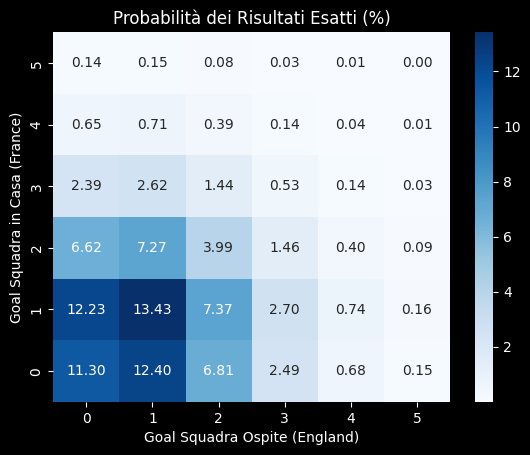


========== SPAIN - ARGENTINA STATISTICS ==========

Spain 1.00 - 0.69 Argentina
C.I. for Spain = [1.0 -- 2.0]
C.I. for Argentina = [0.0 -- 1.0]


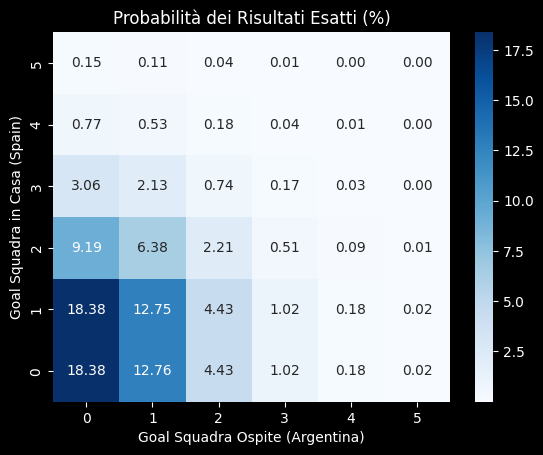

In [83]:
# Adding prediction features

finalist[scal_features] = scaler.transform(finalist[scal_features])

finalist['expected_goals'] = model.predict(finalist)

intervals = model.get_prediction(finalist).conf_int(alpha = 0.05)

finalist['lower_bound'] = np.floor(intervals[:, 0])
finalist['upper_bound'] = np.ceil(intervals[:, 1])

print(finalist)

# Finals predictions

array_goal = np.arange(6)

# Lets predict France-England final score

lambd_home = finalist['expected_goals'].iloc[1]
lambd_away = finalist['expected_goals'].iloc[3]

probhome = poisson.pmf(array_goal, lambd_home)
probaway = poisson.pmf(array_goal, lambd_away)

M = np.outer(probhome, probaway)

matrix = pd.DataFrame(M*100)

print('\n========== FRANCE - ENGLAND STATISTICS ==========')
print(f'\nFrance {lambd_home:.2f} - {lambd_away:.2f} England')
print(f"C.I. for France = [{finalist['lower_bound'].iloc[1]} -- {finalist['upper_bound'].iloc[1]}]")
print(f"C.I. for England = [{finalist['lower_bound'].iloc[3]} -- {finalist['upper_bound'].iloc[3]}]")

plt.style.use('dark_background')
sns.heatmap(matrix, annot=True, fmt=".2f", cmap="Blues", cbar=True)
plt.gca().invert_yaxis()
plt.title("Probabilità dei Risultati Esatti (%)")
plt.ylabel("Goal Squadra in Casa (France)")
plt.xlabel("Goal Squadra Ospite (England)")
plt.show()


# Lets predict Spain-Argentina final score

lambd_home = semi_finalist['expected_goals'].iloc[0]
lambd_away = semi_finalist['expected_goals'].iloc[2]

probhome = poisson.pmf(array_goal, lambd_home)
probaway = poisson.pmf(array_goal, lambd_away)

M = np.outer(probhome, probaway)

print('\n========== SPAIN - ARGENTINA STATISTICS ==========')
print(f'\nSpain {lambd_home:.2f} - {lambd_away:.2f} Argentina')
print(f"C.I. for Spain = [{finalist['lower_bound'].iloc[0]} -- {finalist['upper_bound'].iloc[0]}]")
print(f"C.I. for Argentina = [{finalist['lower_bound'].iloc[2]} -- {finalist['upper_bound'].iloc[2]}]")

matrix = pd.DataFrame(M*100)
plt.style.use('dark_background')
sns.heatmap(matrix, annot=True, fmt=".2f", cmap="Blues", cbar=True)
plt.gca().invert_yaxis()
plt.title("Probabilità dei Risultati Esatti (%)")
plt.ylabel("Goal Squadra in Casa (Spain)")
plt.xlabel("Goal Squadra Ospite (Argentina)")
plt.show()